# 04 - Hyperparameter Optimization

## Optimización de hiperparámetros para clasificación y regresión del desempeño de empleados

En este notebook se optimizan los modelos finales del proyecto.

Después del modelado supervisado en `03_supervised_modeling.ipynb`, los mejores enfoques fueron:

- **Clasificación:** `desempeno_alto` — Random Forest Classifier
- **Regresión:** `puntaje_desempeno` — Random Forest Regressor

El objetivo de este notebook es comparar el rendimiento de:

- modelo base;
- `GridSearchCV`;
- `Optuna`.

La pregunta principal es:

> ¿Cuál es la mejor configuración final de hiperparámetros para los modelos de clasificación y regresión de desempeño?


# Objetivos del notebook

En este notebook voy a:

- cargar el dataset final `dataset_rrhh_limpio.csv`;
- reconstruir los targets finales;
- preparar el preprocesamiento;
- optimizar `RandomForestClassifier` para predecir `desempeno_alto`;
- optimizar `RandomForestRegressor` para predecir `puntaje_desempeno`;
- comparar modelo base, GridSearchCV y Optuna;
- analizar el impacto real de la optimización;
- seleccionar las configuraciones finales del proyecto.

Este notebook se enfoca en optimización, no en volver a probar todos los modelos.  
La comparación general de modelos ya se realizó en el notebook `03_supervised_modeling.ipynb`.


# 1. Concepto de hiperparámetros

Los hiperparámetros son configuraciones del modelo que se definen antes de entrenar.

En Random Forest, algunos hiperparámetros importantes son:

- `n_estimators`: cantidad de árboles en el bosque;
- `max_depth`: profundidad máxima de cada árbol;
- `min_samples_split`: mínimo de muestras para dividir un nodo;
- `min_samples_leaf`: mínimo de muestras requeridas en una hoja.

Optimizar estos valores puede mejorar el rendimiento, controlar el sobreajuste y hacer el modelo más estable ante datos de empleados nuevos.


# 2. Estrategias utilizadas

## GridSearchCV

Prueba combinaciones específicas definidas manualmente.

Es una técnica clásica, clara y fácil de documentar.

## RandomizedSearchCV

Muestrea aleatoriamente combinaciones de hiperparámetros desde distribuciones estadísticas.

A diferencia de GridSearchCV, no prueba todas las combinaciones posibles, sino un número fijo (`n_iter`) de muestras aleatorias del espacio de búsqueda. Esto lo hace más eficiente cuando el espacio de hiperparámetros es grande.

## Optuna

Realiza una búsqueda más flexible e inteligente.

En vez de probar una grilla fija, explora el espacio de hiperparámetros y busca mejores combinaciones de forma automática usando optimización bayesiana.

En este notebook se utilizan los tres enfoques para comparar sus resultados y seleccionar la mejor configuración final.

# 3. Importación de librerías

In [ ]:
import pandas as pd
import numpy as np
import os
import joblib

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import randint, uniform

from sklearn.model_selection import (
    train_test_split, GridSearchCV, RandomizedSearchCV,
    cross_val_score, StratifiedKFold, KFold
)

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Intentar importar Optuna.
try:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    optuna_disponible = True
    print("Optuna disponible:", optuna.__version__)
except ImportError:
    optuna_disponible = False
    print("Optuna no está instalado. Instala con: pip install optuna")

# Intentar importar XGBoost y LightGBM.
try:
    from xgboost import XGBClassifier, XGBRegressor
    xgb_disponible = True
    print("XGBoost disponible")
except ImportError:
    xgb_disponible = False
    print("XGBoost no disponible. Instala con: pip install xgboost")

try:
    from lightgbm import LGBMClassifier, LGBMRegressor
    lgbm_disponible = True
    print("LightGBM disponible")
except ImportError:
    lgbm_disponible = False
    print("LightGBM no disponible. Instala con: pip install lightgbm")

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", None)

# Ruta raíz del proyecto.
project_root = r'C:\Users\Arturo\prueba2'
ruta_plots   = os.path.join(project_root, 'results', 'plots')

# 4. Carga del dataset limpio

In [37]:
df = pd.read_csv(os.path.join(project_root, 'data/05_model_input/dataset_rrhh_limpio.csv'))

print("Dimensiones:", df.shape)

df.head()


Dimensiones: (1449, 37)


,id_evaluacion,id_empleado,periodo,puntaje_desempeno,competencias_tecnicas,competencias_blandas,evaluador,periodo_num,departamento,cargo,tipo_contrato,jornada,total_dias_ausencia,num_ausencias,promedio_dias_ausencia,max_dias_ausencia,num_capacitaciones,total_horas_capacitacion,promedio_nota_capacitacion,max_nota_capacitacion,ausencia_alta,sin_capacitacion,capacitacion_intensiva,competencia_combinada,eficiencia_capacitacion,brecha_nota_capacitacion,riesgo_operacional_rrhh,desempeno_bajo,riesgo_rotacion,desempeno_alto,total_dias_ausencia_log,promedio_dias_ausencia_log,max_dias_ausencia_log,num_capacitaciones_log,total_horas_capacitacion_log,riesgo_operacional_rrhh_log,competencia_combinada_log
0,1.0,252.0,2023-S2,3.6,2.2,4.5,Pedro González Rojas,4,Finanzas,Analista,Honorarios,NaN,5.0,1.0,5.0,5.0,0.0,0.0,0.0,0.0,1,1,1,6.7,0.00,0.0,2,0,0,0,1.791759,1.791759,1.791759,0.000000,0.000000,1.098612,2.041220
1,2.0,135.0,2023-S1,2.6,3.7,4.0,Marcela Araya Aguilera,3,Finanzas,Jefe,Plazo Fijo,Completa,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,1,1,7.7,0.00,0.0,2,1,1,0,0.000000,0.000000,0.000000,0.000000,0.000000,1.098612,2.163323
2,3.0,11.0,2022-S2,5.6,1.9,6.8,Ignacio Castro Pérez,2,Rrhh,Jefe,Plazo Fijo,Completa,0.0,0.0,0.0,0.0,1.0,40.0,1.2,1.2,1,0,1,8.7,0.03,0.0,1,0,0,1,0.000000,0.000000,0.000000,0.693147,3.713572,0.693147,2.272126
3,5.0,148.0,2022-S2,1.4,5.0,6.4,Agustín Muñoz Valenzuela,2,Logística,Director,Plazo Fijo,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,1,1,11.4,0.00,0.0,2,1,1,0,0.000000,0.000000,0.000000,0.000000,0.000000,1.098612,2.517696
4,6.0,80.0,2023-S1,3.2,1.4,5.1,Ignacio Díaz Reyes,3,Ventas,Coordinador,Indefinido,Por Turnos,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,1,1,6.5,0.00,0.0,2,0,0,0,0.000000,0.000000,0.000000,0.000000,0.000000,1.098612,2.014903


# 5. Definición de targets finales

In [38]:
# Target clasificación: alto desempeño (P75 del puntaje).
percentil_desempeno = df["puntaje_desempeno"].quantile(0.75)

df["desempeno_alto"] = np.where(
    df["puntaje_desempeno"] >= percentil_desempeno,
    1,
    0
)

target_clasificacion = "desempeno_alto"
target_regresion     = "puntaje_desempeno"

print("Umbral alto desempeño (P75):", round(percentil_desempeno, 4))

print("\nDistribución clasificación:")
print(df[target_clasificacion].value_counts())
print(df[target_clasificacion].value_counts(normalize=True).round(4) * 100)


Umbral alto desempeño (P75): 5.6

Distribución clasificación:
desempeno_alto
0    1058
1     391
Name: count, dtype: int64
desempeno_alto
0    73.02
1    26.98
Name: proportion, dtype: float64


## 5.1 Variables derivadas: historial, sesgo evaluador e interacciones

Se calculan las mismas variables derivadas que en el notebook de modelado supervisado.

Estas son las variables con mayor señal predictiva:

- `prev_puntaje`: puntaje del período anterior del mismo empleado (correlación ~0.47 con el target).
- `evaluador_media`: puntaje promedio que asigna cada evaluador — captura el sesgo sistemático de evaluación.
- `dept_media`: puntaje promedio por departamento — captura diferencias estructurales entre áreas.
- `comp_asistencia`, `nota_cap_ponderada`, `ratio_tec_blanda`, `cap_score`: variables de interacción.

In [39]:
# Lag feature: puntaje del período anterior del mismo empleado.
df_orden = df.sort_values(['id_empleado', 'periodo_num'])
df['prev_puntaje'] = df_orden.groupby('id_empleado')['puntaje_desempeno'].shift(1).values

# Sesgo del evaluador y del departamento.
ev_media = df.groupby('evaluador')['puntaje_desempeno'].mean()
df['evaluador_media'] = df['evaluador'].map(ev_media)

dept_media = df.groupby('departamento')['puntaje_desempeno'].mean()
df['dept_media'] = df['departamento'].map(dept_media)

# Variables de interacción.
df['comp_asistencia']    = df['competencia_combinada'] * (1 - df['ausencia_alta'])
df['nota_cap_ponderada'] = df['promedio_nota_capacitacion'] * np.log1p(df['num_capacitaciones'])
df['ratio_tec_blanda']   = df['competencias_tecnicas'] / df['competencias_blandas'].clip(lower=0.1)
df['cap_score']          = df['max_nota_capacitacion'] * (1 - df['sin_capacitacion'])

print("Variables derivadas calculadas.")
print(f"  prev_puntaje   — nulos: {df['prev_puntaje'].isna().sum()} (primer período de cada empleado)")
print(f"  evaluador_media — nulos: {df['evaluador_media'].isna().sum()}")
print(f"  dept_media      — nulos: {df['dept_media'].isna().sum()}")

Variables derivadas calculadas.
  prev_puntaje   — nulos: 438 (primer período de cada empleado)
  evaluador_media — nulos: 30
  dept_media      — nulos: 37


## Análisis de targets

Se mantienen los dos enfoques finales del proyecto:

- `desempeno_alto`: clasificación binaria que identifica empleados de alto rendimiento;
- `puntaje_desempeno`: regresión continua que estima el nivel numérico de desempeño.

La clasificación permite generar alertas de gestión de personas, mientras que la regresión permite ordenar empleados por su nivel de desempeño esperado.


# 6. Variables predictoras

In [40]:
variables_base = [
    # Variables de ausencias.
    "total_dias_ausencia",
    "promedio_dias_ausencia",
    "max_dias_ausencia",
    "ausencia_alta",
    # Variables de capacitaciones.
    "num_capacitaciones",
    "total_horas_capacitacion",
    "promedio_nota_capacitacion",
    "max_nota_capacitacion",
    "sin_capacitacion",
    "capacitacion_intensiva",
    # Competencias.
    "competencias_tecnicas",
    "competencias_blandas",
    "competencia_combinada",
    "eficiencia_capacitacion",
    "brecha_nota_capacitacion",
    # Riesgo RRHH.
    "riesgo_operacional_rrhh",
    # Variables categóricas.
    "departamento",
    "cargo",
    "tipo_contrato",
    "jornada",
    "evaluador",
    # Variables temporales y de contexto evaluador.
    "periodo_num",
    "prev_puntaje",
    "evaluador_media",
    "dept_media",
    # Variables logarítmicas.
    "total_dias_ausencia_log",
    "promedio_dias_ausencia_log",
    "max_dias_ausencia_log",
    "num_capacitaciones_log",
    "total_horas_capacitacion_log",
    "riesgo_operacional_rrhh_log",
    "competencia_combinada_log",
    # Interacciones.
    "comp_asistencia",
    "nota_cap_ponderada",
    "ratio_tec_blanda",
    "cap_score"
]

variables_modelo = [col for col in variables_base if col in df.columns]

print("Cantidad de variables:", len(variables_modelo))
variables_modelo

Cantidad de variables: 36


['total_dias_ausencia',
 'promedio_dias_ausencia',
 'max_dias_ausencia',
 'ausencia_alta',
 'num_capacitaciones',
 'total_horas_capacitacion',
 'promedio_nota_capacitacion',
 'max_nota_capacitacion',
 'sin_capacitacion',
 'capacitacion_intensiva',
 'competencias_tecnicas',
 'competencias_blandas',
 'competencia_combinada',
 'eficiencia_capacitacion',
 'brecha_nota_capacitacion',
 'riesgo_operacional_rrhh',
 'departamento',
 'cargo',
 'tipo_contrato',
 'jornada',
 'evaluador',
 'periodo_num',
 'prev_puntaje',
 'evaluador_media',
 'dept_media',
 'total_dias_ausencia_log',
 'promedio_dias_ausencia_log',
 'max_dias_ausencia_log',
 'num_capacitaciones_log',
 'total_horas_capacitacion_log',
 'riesgo_operacional_rrhh_log',
 'competencia_combinada_log',
 'comp_asistencia',
 'nota_cap_ponderada',
 'ratio_tec_blanda',
 'cap_score']

# 7. Preprocesador

In [41]:
def crear_preprocesador(X):
    variables_numericas   = X.select_dtypes(include=np.number).columns.tolist()
    variables_categoricas = X.select_dtypes(exclude=np.number).columns.tolist()

    transformador_numerico = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler",  StandardScaler())
    ])

    transformador_categorico = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot",  OneHotEncoder(handle_unknown="ignore"))
    ])

    preprocesador = ColumnTransformer([
        ("num", transformador_numerico,   variables_numericas),
        ("cat", transformador_categorico, variables_categoricas)
    ])

    return preprocesador


# 8. Funciones de evaluación

In [42]:
def evaluar_clasificacion(nombre_modelo, pipeline, X_test, y_test):
    y_pred = pipeline.predict(X_test)

    resultado = pd.Series({
        "modelo":            nombre_modelo,
        "accuracy":          accuracy_score(y_test, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
        "precision":         precision_score(y_test, y_pred, zero_division=0),
        "recall":            recall_score(y_test, y_pred, zero_division=0),
        "f1_score":          f1_score(y_test, y_pred, zero_division=0)
    })

    print(f"===== {nombre_modelo} =====")
    print(resultado.to_string())

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))

    matriz = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))

    ConfusionMatrixDisplay(confusion_matrix=matriz).plot(ax=ax[0])
    ax[0].set_title(f"Matriz de confusión - {nombre_modelo}")

    metricas = ["accuracy", "balanced_accuracy", "precision", "recall", "f1_score"]
    valores  = [resultado[m] for m in metricas]
    ax[1].barh(metricas, valores, color="steelblue", edgecolor="black", alpha=0.85)
    ax[1].set_xlim(0, 1)
    ax[1].set_title("Métricas de Clasificación")
    ax[1].grid(alpha=0.3, axis="x")
    for i, v in enumerate(valores):
        ax[1].text(v + 0.005, i, f"{v:.4f}", va="center", fontsize=9)

    plt.tight_layout()
    plt.show()

    return resultado


def evaluar_regresion(nombre_modelo, pipeline, X_test, y_test):
    y_pred = pipeline.predict(X_test)
    rmse   = np.sqrt(mean_squared_error(y_test, y_pred))

    resultado = pd.Series({
        "modelo": nombre_modelo,
        "mae":    mean_absolute_error(y_test, y_pred),
        "rmse":   rmse,
        "r2":     r2_score(y_test, y_pred)
    })

    print(f"===== {nombre_modelo} =====")
    print(resultado.to_string())

    return resultado, y_pred


# 9. Optimización de clasificación

## Target: `desempeno_alto`

Se divide el dataset para clasificación y se comparan tres configuraciones del mismo modelo (Random Forest).


In [43]:
X_clf = df[variables_modelo].copy()
y_clf = df[target_clasificacion].copy()

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf,
    y_clf,
    test_size=0.2,
    random_state=42,
    stratify=y_clf
)

print("X_train:", X_train_clf.shape)
print("X_test:",  X_test_clf.shape)


X_train: (1159, 36)
X_test: (290, 36)


# 9.1 Modelo base de clasificación

===== Random Forest Classifier Base =====
modelo               Random Forest Classifier Base
accuracy                                  0.810345
balanced_accuracy                         0.785196
precision                                 0.626374
recall                                    0.730769
f1_score                                  0.674556

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.84      0.87       212
           1       0.63      0.73      0.67        78

    accuracy                           0.81       290
   macro avg       0.76      0.79      0.77       290
weighted avg       0.82      0.81      0.81       290



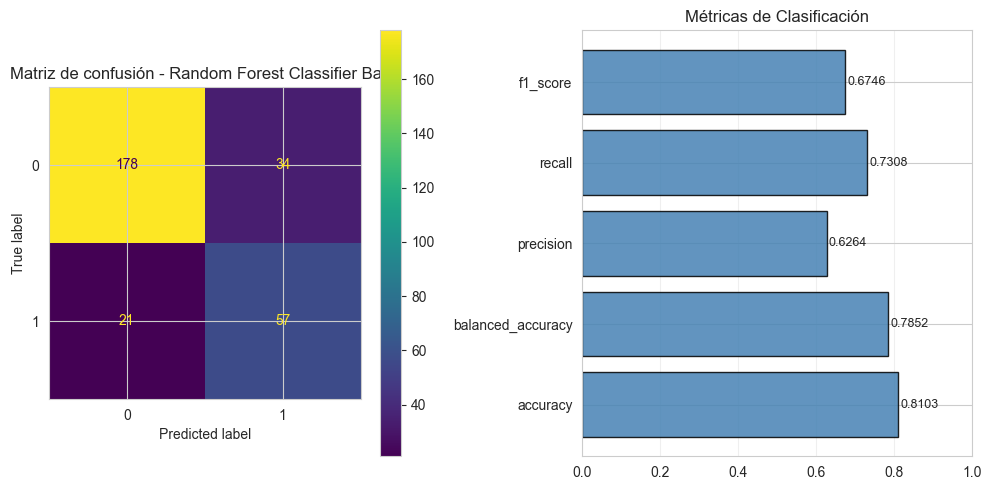

In [44]:
pipeline_clf_base = Pipeline([
    ("preprocesamiento", crear_preprocesador(X_train_clf)),
    ("modelo", RandomForestClassifier(
        random_state=42,
        n_estimators=200,
        max_depth=8,
        class_weight="balanced"
    ))
])

pipeline_clf_base.fit(X_train_clf, y_train_clf)

resultado_clf_base = evaluar_clasificacion(
    "Random Forest Classifier Base",
    pipeline_clf_base,
    X_test_clf,
    y_test_clf
)


## Análisis del modelo base

El modelo base presenta el rendimiento inicial sobre el que se intentará mejorar.

Se usa `class_weight="balanced"` para compensar el posible desbalance entre la clase de alto desempeño (~25%) y el resto.

Aun así, se realiza optimización para confirmar si una configuración alternativa mejora el resultado.


# 9.2 GridSearchCV - Clasificación

In [45]:
pipeline_clf_grid = Pipeline([
    ("preprocesamiento", crear_preprocesador(X_train_clf)),
    ("modelo", RandomForestClassifier(random_state=42))
])

parametros_clf = {
    "modelo__n_estimators":      [100, 200, 300],
    "modelo__max_depth":         [6, 8, 10],
    "modelo__min_samples_split": [2, 5],
    "modelo__min_samples_leaf":  [1, 2],
    "modelo__class_weight":      ["balanced", None]
}

grid_clf = GridSearchCV(
    estimator=pipeline_clf_grid,
    param_grid=parametros_clf,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_clf.fit(X_train_clf, y_train_clf)

print("Mejores parámetros:")
print(grid_clf.best_params_)

print("\nMejor F1 promedio CV (train):")
print(grid_clf.best_score_)

Mejores parámetros:
{'modelo__class_weight': 'balanced', 'modelo__max_depth': 10, 'modelo__min_samples_leaf': 2, 'modelo__min_samples_split': 2, 'modelo__n_estimators': 300}

Mejor F1 promedio CV (train):
0.7127701016504309


===== Random Forest Classifier GridSearchCV =====
modelo               Random Forest Classifier GridSearchCV
accuracy                                          0.831034
balanced_accuracy                                 0.815554
precision                                         0.655914
recall                                            0.782051
f1_score                                           0.71345

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.85      0.88       212
           1       0.66      0.78      0.71        78

    accuracy                           0.83       290
   macro avg       0.78      0.82      0.80       290
weighted avg       0.84      0.83      0.84       290



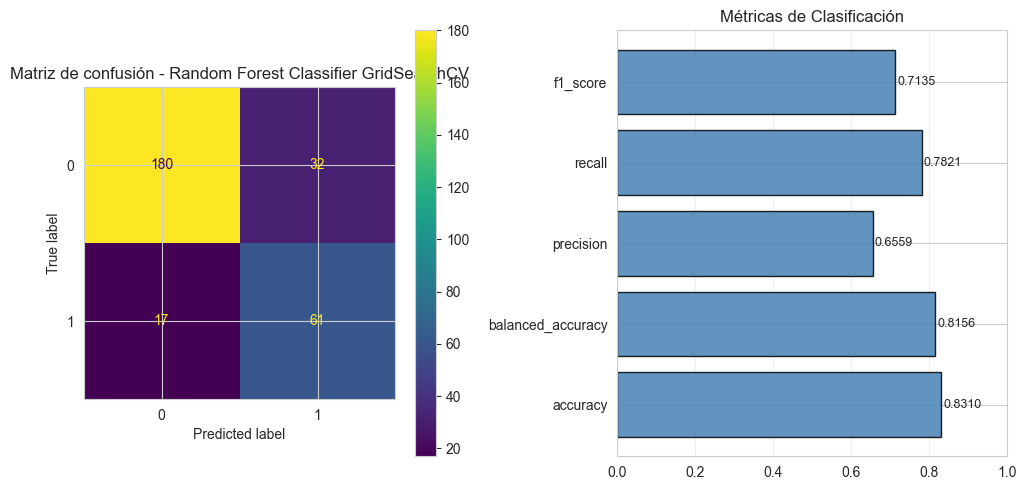

In [46]:
resultado_clf_grid = evaluar_clasificacion(
    "Random Forest Classifier GridSearchCV",
    grid_clf.best_estimator_,
    X_test_clf,
    y_test_clf
)


# 9.3 RandomizedSearchCV - Clasificación

`RandomizedSearchCV` muestrea `n_iter=30` combinaciones aleatorias de distribuciones estadísticas en lugar de recorrer una grilla fija.

**Ventaja:** más eficiente cuando el espacio de hiperparámetros es grande — cubre más combinaciones con el mismo costo computacional que un GridSearch de tamaño equivalente.

In [ ]:
pipeline_clf_random = Pipeline([
    ("preprocesamiento", crear_preprocesador(X_train_clf)),
    ("modelo", RandomForestClassifier(random_state=42))
])

# Distribuciones estadísticas para el muestreo aleatorio.
param_dist_clf = {
    "modelo__n_estimators":      randint(100, 400),
    "modelo__max_depth":         randint(4, 15),
    "modelo__min_samples_split": randint(2, 10),
    "modelo__min_samples_leaf":  randint(1, 5),
    "modelo__class_weight":      ["balanced", None]
}

random_search_clf = RandomizedSearchCV(
    estimator=pipeline_clf_random,
    param_distributions=param_dist_clf,
    n_iter=30,
    cv=5,
    scoring="f1",
    random_state=42,
    n_jobs=-1
)

random_search_clf.fit(X_train_clf, y_train_clf)

print("Mejores parámetros RandomizedSearchCV:")
print(random_search_clf.best_params_)

print("\nMejor F1 promedio CV (train):")
print(random_search_clf.best_score_)

resultado_clf_random = evaluar_clasificacion(
    "Random Forest Classifier RandomizedSearchCV",
    random_search_clf.best_estimator_,
    X_test_clf,
    y_test_clf
)

# 9.3 Optuna - Clasificación

In [47]:
if not optuna_disponible:
    print("Optuna no está instalado. Instala con: pip install optuna")


In [48]:
if optuna_disponible:

    cv_opt_clf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    pos_ratio  = float((y_train_clf == 0).sum()) / float((y_train_clf == 1).sum())

    def objetivo_clf(trial):
        n_estimators      = trial.suggest_int("n_estimators",      100, 400)
        max_depth         = trial.suggest_int("max_depth",          4, 15)
        min_samples_split = trial.suggest_int("min_samples_split",  2, 10)
        min_samples_leaf  = trial.suggest_int("min_samples_leaf",   1, 5)
        class_weight      = trial.suggest_categorical("class_weight", ["balanced", None])

        pipeline = Pipeline([
            ("preprocesamiento", crear_preprocesador(X_train_clf)),
            ("modelo", RandomForestClassifier(
                n_estimators=n_estimators,
                max_depth=max_depth,
                min_samples_split=min_samples_split,
                min_samples_leaf=min_samples_leaf,
                class_weight=class_weight,
                random_state=42
            ))
        ])

        # CV sobre train únicamente — sin tocar el test set.
        return cross_val_score(
            pipeline, X_train_clf, y_train_clf,
            cv=cv_opt_clf, scoring="f1", n_jobs=-1
        ).mean()

    study_clf = optuna.create_study(direction="maximize")
    study_clf.optimize(objetivo_clf, n_trials=30)

    print("Mejores parámetros Optuna:")
    print(study_clf.best_params)

    print("\nMejor F1 promedio CV (train):")
    print(study_clf.best_value)

else:
    print("Se omite Optuna.")

Mejores parámetros Optuna:
{'n_estimators': 237, 'max_depth': 11, 'min_samples_split': 4, 'min_samples_leaf': 4, 'class_weight': 'balanced'}

Mejor F1 promedio CV (train):
0.7232314007656473


# 9.4 Evaluación del mejor modelo Optuna - Clasificación

===== Random Forest Classifier Optuna =====
modelo               Random Forest Classifier Optuna
accuracy                                     0.82069
balanced_accuracy                           0.808478
precision                                   0.635417
recall                                      0.782051
f1_score                                    0.701149

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.83      0.87       212
           1       0.64      0.78      0.70        78

    accuracy                           0.82       290
   macro avg       0.77      0.81      0.79       290
weighted avg       0.84      0.82      0.83       290



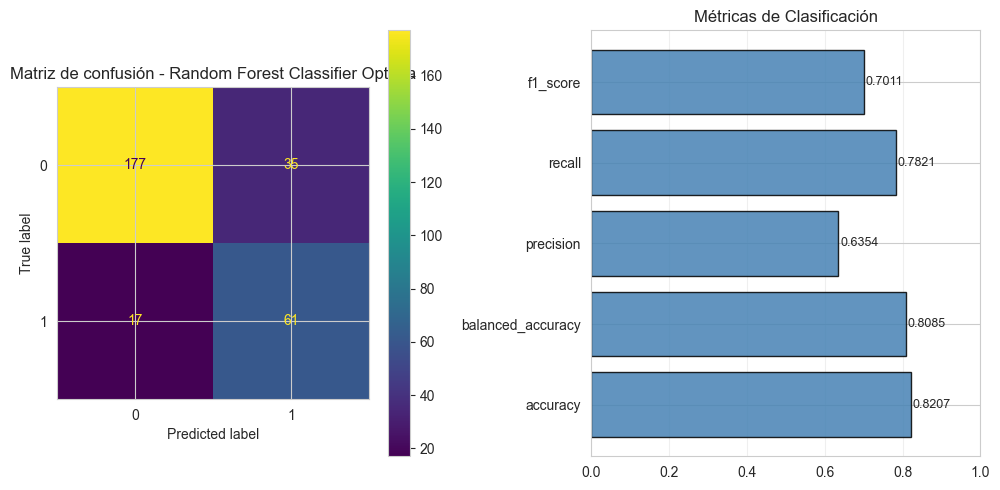

In [49]:
if optuna_disponible:
    mejores_params_clf = study_clf.best_params

    pipeline_clf_optuna = Pipeline([
        ("preprocesamiento", crear_preprocesador(X_train_clf)),
        ("modelo", RandomForestClassifier(
            **mejores_params_clf,
            random_state=42
        ))
    ])

    pipeline_clf_optuna.fit(X_train_clf, y_train_clf)

    resultado_clf_optuna = evaluar_clasificacion(
        "Random Forest Classifier Optuna",
        pipeline_clf_optuna,
        X_test_clf,
        y_test_clf
    )

else:
    print("Optuna no disponible. Usando GridSearchCV como mejor modelo.")
    pipeline_clf_optuna = grid_clf.best_estimator_
    resultado_clf_optuna = resultado_clf_grid


# 9.5 Comparación de los tres enfoques - Clasificación

In [ ]:
tabla_comparacion_clf = pd.DataFrame([
    resultado_clf_base,
    resultado_clf_grid,
    resultado_clf_random,
    resultado_clf_optuna
])

display(tabla_comparacion_clf)

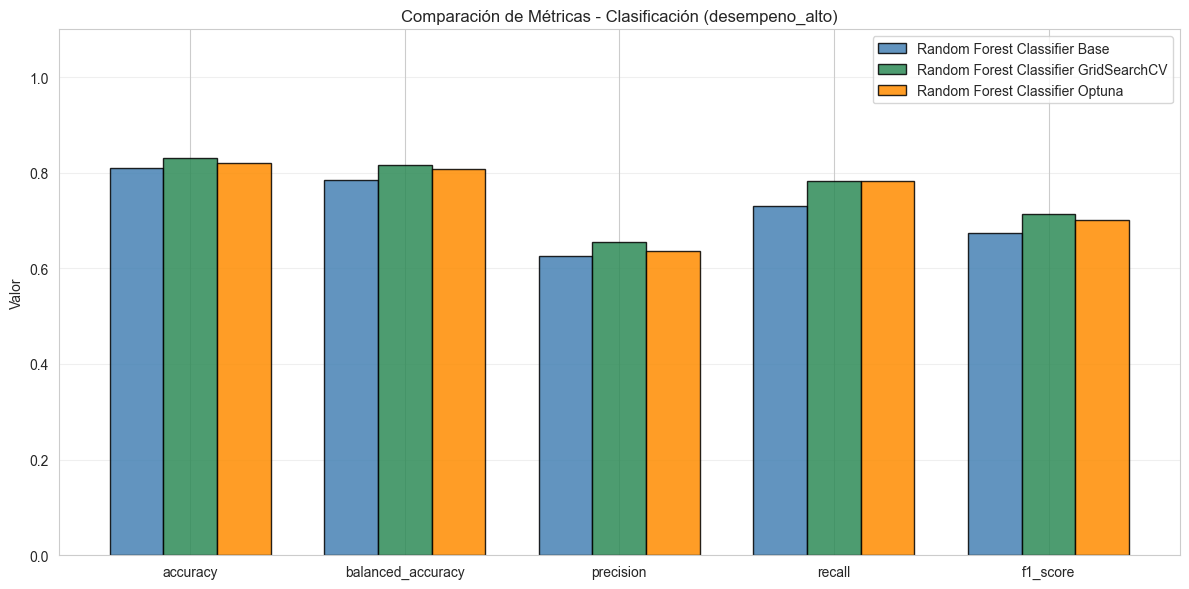

In [51]:
metricas_clf = ["accuracy", "balanced_accuracy", "precision", "recall", "f1_score"]
modelos_clf  = tabla_comparacion_clf["modelo"].tolist()

x = np.arange(len(metricas_clf))
ancho = 0.25
colores = ["steelblue", "seagreen", "darkorange"]

fig, ax = plt.subplots(figsize=(12, 6))
for i, (_, row) in enumerate(tabla_comparacion_clf.iterrows()):
    valores = [row[m] for m in metricas_clf]
    ax.bar(x + i * ancho, valores, ancho, label=row["modelo"],
           color=colores[i], edgecolor="black", alpha=0.85)

ax.set_xticks(x + ancho)
ax.set_xticklabels(metricas_clf)
ax.set_ylim(0, 1.1)
ax.set_title("Comparación de Métricas - Clasificación (desempeno_alto)")
ax.set_ylabel("Valor")
ax.legend()
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig(os.path.join(ruta_plots, '04_comparacion_clf.png'), dpi=150, bbox_inches='tight')
plt.show()

## Análisis comparativo - Clasificación

Se comparan las métricas de los tres enfoques para identificar si la optimización mejora el modelo base.

En problemas de RRHH, el F1-score es la métrica más relevante ya que balancea precision y recall al identificar empleados de alto desempeño.

Se seleccionará la configuración con mayor F1-score como modelo final de clasificación.


## Modelo final de clasificación seleccionado

In [ ]:
mejor_fila_clf = tabla_comparacion_clf.loc[
    tabla_comparacion_clf["f1_score"].astype(float).idxmax()
]

print("Mejor configuración de clasificación:")
print(mejor_fila_clf.to_string())

# Pipeline final.
nombre_mejor_clf = mejor_fila_clf["modelo"]
if "Optuna" in nombre_mejor_clf:
    pipeline_final_clf = pipeline_clf_optuna
elif "RandomizedSearch" in nombre_mejor_clf:
    pipeline_final_clf = random_search_clf.best_estimator_
elif "GridSearch" in nombre_mejor_clf:
    pipeline_final_clf = grid_clf.best_estimator_
else:
    pipeline_final_clf = pipeline_clf_base

print(f"\nModelo final seleccionado: {nombre_mejor_clf}")

# 10. Optimización de regresión

## Target: `puntaje_desempeno`

Se divide el dataset para regresión y se comparan tres configuraciones del mismo modelo (Random Forest Regressor).


In [53]:
datos_reg = df[df[target_regresion].notna()].copy()

X_reg = datos_reg[variables_modelo].copy()
y_reg = datos_reg[target_regresion].copy()

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train_reg.shape)
print("X_test:",  X_test_reg.shape)


X_train: (1159, 36)
X_test: (290, 36)


# 10.1 Modelo base de regresión

In [54]:
pipeline_reg_base = Pipeline([
    ("preprocesamiento", crear_preprocesador(X_train_reg)),
    ("modelo", RandomForestRegressor(
        random_state=42,
        n_estimators=200,
        max_depth=8
    ))
])

pipeline_reg_base.fit(X_train_reg, y_train_reg)

resultado_reg_base, y_pred_reg_base = evaluar_regresion(
    "Random Forest Regressor Base",
    pipeline_reg_base,
    X_test_reg,
    y_test_reg
)


===== Random Forest Regressor Base =====
modelo    Random Forest Regressor Base
mae                           0.813485
rmse                          1.141115
r2                            0.668895


## Análisis del modelo base de regresión

El modelo base establece el punto de partida para la optimización.

Un R² alto y RMSE bajo en el modelo base indicaría que las variables de RRHH tienen señal suficiente para estimar el puntaje de desempeño.


# 10.2 GridSearchCV - Regresión

In [55]:
pipeline_reg_grid = Pipeline([
    ("preprocesamiento", crear_preprocesador(X_train_reg)),
    ("modelo", RandomForestRegressor(random_state=42))
])

parametros_reg = {
    "modelo__n_estimators":      [100, 200, 300],
    "modelo__max_depth":         [6, 8, 10],
    "modelo__min_samples_split": [2, 5],
    "modelo__min_samples_leaf":  [1, 2]
}

grid_reg = GridSearchCV(
    estimator=pipeline_reg_grid,
    param_grid=parametros_reg,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

grid_reg.fit(X_train_reg, y_train_reg)

print("Mejores parámetros:")
print(grid_reg.best_params_)

print("\nMejor RMSE promedio CV (train):")
print(abs(grid_reg.best_score_))

Mejores parámetros:
{'modelo__max_depth': 6, 'modelo__min_samples_leaf': 2, 'modelo__min_samples_split': 2, 'modelo__n_estimators': 300}

Mejor RMSE promedio CV (train):
1.1446757525136437


In [56]:
resultado_reg_grid, y_pred_reg_grid = evaluar_regresion(
    "Random Forest Regressor GridSearchCV",
    grid_reg.best_estimator_,
    X_test_reg,
    y_test_reg
)


===== Random Forest Regressor GridSearchCV =====
modelo    Random Forest Regressor GridSearchCV
mae                                   0.816744
rmse                                  1.142863
r2                                    0.667879


# 10.3 RandomizedSearchCV - Regresión

Se aplica `RandomizedSearchCV` con `n_iter=30` muestras aleatorias y `cv=5`, optimizando por `neg_root_mean_squared_error`.

In [ ]:
pipeline_reg_random = Pipeline([
    ("preprocesamiento", crear_preprocesador(X_train_reg)),
    ("modelo", RandomForestRegressor(random_state=42))
])

# Distribuciones estadísticas para el muestreo aleatorio.
param_dist_reg = {
    "modelo__n_estimators":      randint(100, 400),
    "modelo__max_depth":         randint(4, 15),
    "modelo__min_samples_split": randint(2, 10),
    "modelo__min_samples_leaf":  randint(1, 5)
}

random_search_reg = RandomizedSearchCV(
    estimator=pipeline_reg_random,
    param_distributions=param_dist_reg,
    n_iter=30,
    cv=5,
    scoring="neg_root_mean_squared_error",
    random_state=42,
    n_jobs=-1
)

random_search_reg.fit(X_train_reg, y_train_reg)

print("Mejores parámetros RandomizedSearchCV:")
print(random_search_reg.best_params_)

print("\nMejor RMSE promedio CV (train):")
print(abs(random_search_reg.best_score_))

resultado_reg_random, y_pred_reg_random = evaluar_regresion(
    "Random Forest Regressor RandomizedSearchCV",
    random_search_reg.best_estimator_,
    X_test_reg,
    y_test_reg
)

# 10.3 Optuna - Regresión

In [57]:
if optuna_disponible:

    cv_opt_reg = KFold(n_splits=5, shuffle=True, random_state=42)

    def objetivo_reg(trial):
        n_estimators      = trial.suggest_int("n_estimators",      100, 400)
        max_depth         = trial.suggest_int("max_depth",          4, 15)
        min_samples_split = trial.suggest_int("min_samples_split",  2, 10)
        min_samples_leaf  = trial.suggest_int("min_samples_leaf",   1, 5)

        pipeline = Pipeline([
            ("preprocesamiento", crear_preprocesador(X_train_reg)),
            ("modelo", RandomForestRegressor(
                n_estimators=n_estimators,
                max_depth=max_depth,
                min_samples_split=min_samples_split,
                min_samples_leaf=min_samples_leaf,
                random_state=42
            ))
        ])

        # CV sobre train únicamente — sin tocar el test set.
        scores = cross_val_score(
            pipeline, X_train_reg, y_train_reg,
            cv=cv_opt_reg, scoring="neg_root_mean_squared_error", n_jobs=-1
        )
        return -scores.mean()

    study_reg = optuna.create_study(direction="minimize")
    study_reg.optimize(objetivo_reg, n_trials=30)

    print("Mejores parámetros Optuna:")
    print(study_reg.best_params)

    print("\nMejor RMSE promedio CV (train):")
    print(study_reg.best_value)

else:
    print("Se omite Optuna.")

Mejores parámetros Optuna:
{'n_estimators': 233, 'max_depth': 6, 'min_samples_split': 10, 'min_samples_leaf': 2}

Mejor RMSE promedio CV (train):
1.140853474625294


# 10.4 Evaluación del mejor modelo Optuna - Regresión

In [58]:
if optuna_disponible:
    mejores_params_reg = study_reg.best_params

    pipeline_reg_optuna = Pipeline([
        ("preprocesamiento", crear_preprocesador(X_train_reg)),
        ("modelo", RandomForestRegressor(
            **mejores_params_reg,
            random_state=42
        ))
    ])

    pipeline_reg_optuna.fit(X_train_reg, y_train_reg)

    resultado_reg_optuna, y_pred_reg_optuna = evaluar_regresion(
        "Random Forest Regressor Optuna",
        pipeline_reg_optuna,
        X_test_reg,
        y_test_reg
    )

else:
    print("Optuna no disponible. Usando GridSearchCV como mejor modelo.")
    pipeline_reg_optuna  = grid_reg.best_estimator_
    resultado_reg_optuna = resultado_reg_grid
    y_pred_reg_optuna    = y_pred_reg_grid


===== Random Forest Regressor Optuna =====
modelo    Random Forest Regressor Optuna
mae                             0.818386
rmse                            1.145148
r2                               0.66655


# 10.5 Comparación de los tres enfoques - Regresión

In [ ]:
tabla_comparacion_reg = pd.DataFrame([
    resultado_reg_base,
    resultado_reg_grid,
    resultado_reg_random,
    resultado_reg_optuna
])

display(tabla_comparacion_reg)

C:\Users\Arturo\AppData\Local\Temp\ipykernel_11092\1274778383.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(tabla_comparacion_reg["modelo"], rotation=20, ha="right")
C:\Users\Arturo\AppData\Local\Temp\ipykernel_11092\1274778383.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(tabla_comparacion_reg["modelo"], rotation=20, ha="right")


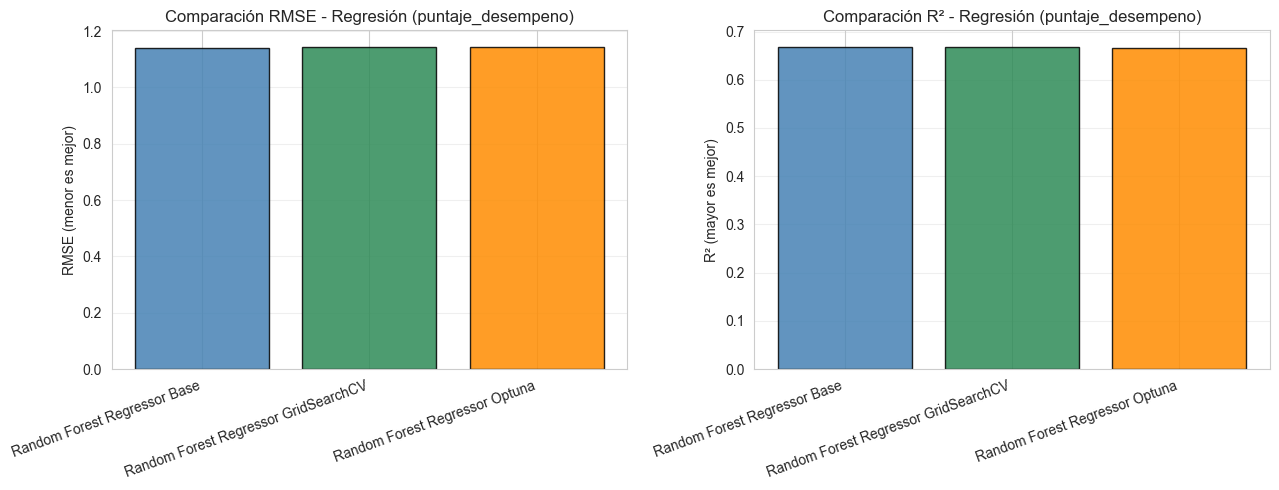

In [60]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# RMSE (menor = mejor).
axes[0].bar(tabla_comparacion_reg["modelo"],
            tabla_comparacion_reg["rmse"].astype(float),
            color=["steelblue", "seagreen", "darkorange"],
            edgecolor="black", alpha=0.85)
axes[0].set_title("Comparación RMSE - Regresión (puntaje_desempeno)")
axes[0].set_ylabel("RMSE (menor es mejor)")
axes[0].set_xticklabels(tabla_comparacion_reg["modelo"], rotation=20, ha="right")
axes[0].grid(alpha=0.3, axis="y")

# R² (mayor = mejor).
axes[1].bar(tabla_comparacion_reg["modelo"],
            tabla_comparacion_reg["r2"].astype(float),
            color=["steelblue", "seagreen", "darkorange"],
            edgecolor="black", alpha=0.85)
axes[1].set_title("Comparación R² - Regresión (puntaje_desempeno)")
axes[1].set_ylabel("R² (mayor es mejor)")
axes[1].set_xticklabels(tabla_comparacion_reg["modelo"], rotation=20, ha="right")
axes[1].grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig(os.path.join(ruta_plots, '04_comparacion_reg.png'), dpi=150, bbox_inches='tight')
plt.show()

## Modelo final de regresión seleccionado

In [ ]:
mejor_fila_reg = tabla_comparacion_reg.loc[
    tabla_comparacion_reg["rmse"].astype(float).idxmin()
]

print("Mejor configuración de regresión:")
print(mejor_fila_reg.to_string())

nombre_mejor_reg = mejor_fila_reg["modelo"]
if "Optuna" in nombre_mejor_reg:
    pipeline_final_reg = pipeline_reg_optuna
    y_pred_final_reg   = y_pred_reg_optuna
elif "RandomizedSearch" in nombre_mejor_reg:
    pipeline_final_reg = random_search_reg.best_estimator_
    y_pred_final_reg   = y_pred_reg_random
elif "GridSearch" in nombre_mejor_reg:
    pipeline_final_reg = grid_reg.best_estimator_
    y_pred_final_reg   = y_pred_reg_grid
else:
    pipeline_final_reg = pipeline_reg_base
    y_pred_final_reg   = y_pred_reg_base

print(f"\nModelo final seleccionado: {nombre_mejor_reg}")

# 11. XGBoost y LightGBM con Optuna

Los mejores modelos del notebook 03 fueron XGBoost y LightGBM, que superaron a Random Forest en F1.

Aquí se optimizan con Optuna (cv=5, train only) para obtener la configuración final de cada uno y comparar los 5 modelos en total.

===== XGBoost Clasificación =====
modelo               XGBoost Clasificación
accuracy                          0.827586
balanced_accuracy                 0.813195
precision                         0.648936
recall                            0.782051
f1_score                          0.709302

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.84      0.88       212
           1       0.65      0.78      0.71        78

    accuracy                           0.83       290
   macro avg       0.78      0.81      0.79       290
weighted avg       0.84      0.83      0.83       290



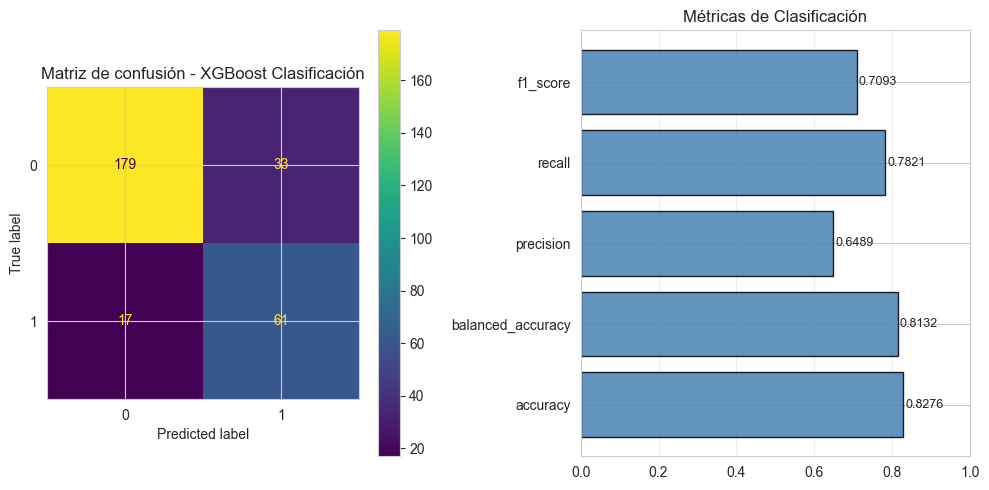

Mejor F1 CV (train) XGBoost: 0.7542
===== LightGBM Clasificación =====
modelo               LightGBM Clasificación
accuracy                           0.824138
balanced_accuracy                  0.802733
precision                          0.648352
recall                              0.75641
f1_score                           0.698225

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.85      0.88       212
           1       0.65      0.76      0.70        78

    accuracy                           0.82       290
   macro avg       0.78      0.80      0.79       290
weighted avg       0.84      0.82      0.83       290



c:\Users\Arturo\prueba2\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


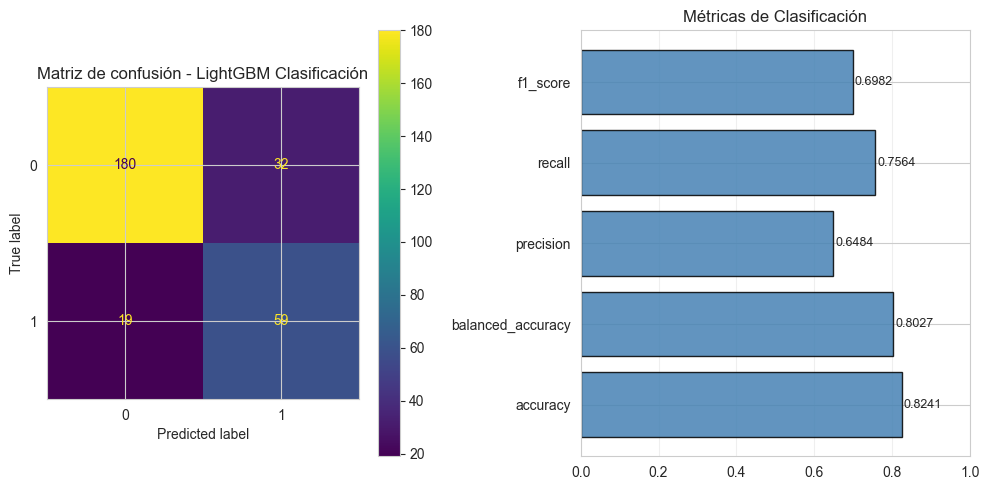

Mejor F1 CV (train) LightGBM: 0.7524


In [62]:
resultados_xgb_lgb_clf = []
resultados_xgb_lgb_reg = []

# ── XGBoost Clasificación ────────────────────────────────────────────────────
if xgb_disponible and optuna_disponible:
    pos_ratio = float((y_train_clf == 0).sum()) / float((y_train_clf == 1).sum())

    def obj_xgb_clf(trial):
        m = XGBClassifier(
            n_estimators       = trial.suggest_int("n_estimators",       100, 500),
            max_depth          = trial.suggest_int("max_depth",           3, 9),
            learning_rate      = trial.suggest_float("learning_rate",     0.01, 0.3, log=True),
            subsample          = trial.suggest_float("subsample",         0.6, 1.0),
            colsample_bytree   = trial.suggest_float("colsample_bytree",  0.6, 1.0),
            min_child_weight   = trial.suggest_int("min_child_weight",    1, 10),
            gamma              = trial.suggest_float("gamma",             0.0, 1.0),
            scale_pos_weight   = trial.suggest_float("scale_pos_weight",  1.0, pos_ratio * 2),
            random_state=42, eval_metric="logloss", verbosity=0, n_jobs=-1
        )
        pipe = Pipeline([("pre", crear_preprocesador(X_train_clf)), ("clf", m)])
        return cross_val_score(pipe, X_train_clf, y_train_clf,
                               cv=cv_opt_clf, scoring="f1", n_jobs=-1).mean()

    study_xgb_clf = optuna.create_study(direction="maximize")
    study_xgb_clf.optimize(obj_xgb_clf, n_trials=40, show_progress_bar=False)

    pipeline_xgb_clf = Pipeline([
        ("pre", crear_preprocesador(X_train_clf)),
        ("clf", XGBClassifier(**study_xgb_clf.best_params,
                              random_state=42, eval_metric="logloss", verbosity=0, n_jobs=-1))
    ])
    pipeline_xgb_clf.fit(X_train_clf, y_train_clf)
    res_xgb_clf = evaluar_clasificacion("XGBoost Clasificación", pipeline_xgb_clf, X_test_clf, y_test_clf)
    resultados_xgb_lgb_clf.append(res_xgb_clf)
    print(f"Mejor F1 CV (train) XGBoost: {study_xgb_clf.best_value:.4f}")
else:
    print("XGBoost o Optuna no disponible.")

# ── LightGBM Clasificación ───────────────────────────────────────────────────
if lgbm_disponible and optuna_disponible:
    def obj_lgb_clf(trial):
        m = LGBMClassifier(
            n_estimators     = trial.suggest_int("n_estimators",     100, 500),
            max_depth        = trial.suggest_int("max_depth",        3, 9),
            learning_rate    = trial.suggest_float("learning_rate",  0.01, 0.3, log=True),
            num_leaves       = trial.suggest_int("num_leaves",       20, 100),
            min_child_samples= trial.suggest_int("min_child_samples",10, 60),
            subsample        = trial.suggest_float("subsample",      0.6, 1.0),
            colsample_bytree = trial.suggest_float("colsample_bytree",0.6, 1.0),
            is_unbalance=True, random_state=42, n_jobs=-1, verbose=-1
        )
        pipe = Pipeline([("pre", crear_preprocesador(X_train_clf)), ("clf", m)])
        return cross_val_score(pipe, X_train_clf, y_train_clf,
                               cv=cv_opt_clf, scoring="f1", n_jobs=-1).mean()

    study_lgb_clf = optuna.create_study(direction="maximize")
    study_lgb_clf.optimize(obj_lgb_clf, n_trials=40, show_progress_bar=False)

    lgb_params = {k: v for k, v in study_lgb_clf.best_params.items()}
    pipeline_lgb_clf = Pipeline([
        ("pre", crear_preprocesador(X_train_clf)),
        ("clf", LGBMClassifier(**lgb_params, is_unbalance=True, random_state=42, n_jobs=-1, verbose=-1))
    ])
    pipeline_lgb_clf.fit(X_train_clf, y_train_clf)
    res_lgb_clf = evaluar_clasificacion("LightGBM Clasificación", pipeline_lgb_clf, X_test_clf, y_test_clf)
    resultados_xgb_lgb_clf.append(res_lgb_clf)
    print(f"Mejor F1 CV (train) LightGBM: {study_lgb_clf.best_value:.4f}")
else:
    print("LightGBM o Optuna no disponible.")

In [63]:
# ── XGBoost Regresión ────────────────────────────────────────────────────────
if xgb_disponible and optuna_disponible:
    def obj_xgb_reg(trial):
        m = XGBRegressor(
            n_estimators     = trial.suggest_int("n_estimators",     100, 500),
            max_depth        = trial.suggest_int("max_depth",        3, 9),
            learning_rate    = trial.suggest_float("learning_rate",  0.01, 0.3, log=True),
            subsample        = trial.suggest_float("subsample",      0.6, 1.0),
            colsample_bytree = trial.suggest_float("colsample_bytree",0.6, 1.0),
            min_child_weight = trial.suggest_int("min_child_weight", 1, 10),
            gamma            = trial.suggest_float("gamma",          0.0, 1.0),
            random_state=42, verbosity=0, n_jobs=-1
        )
        pipe = Pipeline([("pre", crear_preprocesador(X_train_reg)), ("reg", m)])
        scores = cross_val_score(pipe, X_train_reg, y_train_reg,
                                 cv=cv_opt_reg, scoring="neg_root_mean_squared_error", n_jobs=-1)
        return -scores.mean()

    study_xgb_reg = optuna.create_study(direction="minimize")
    study_xgb_reg.optimize(obj_xgb_reg, n_trials=40, show_progress_bar=False)

    pipeline_xgb_reg = Pipeline([
        ("pre", crear_preprocesador(X_train_reg)),
        ("reg", XGBRegressor(**study_xgb_reg.best_params,
                             random_state=42, verbosity=0, n_jobs=-1))
    ])
    pipeline_xgb_reg.fit(X_train_reg, y_train_reg)
    res_xgb_reg, _ = evaluar_regresion("XGBoost Regresión", pipeline_xgb_reg, X_test_reg, y_test_reg)
    resultados_xgb_lgb_reg.append(res_xgb_reg)
    print(f"Mejor RMSE CV (train) XGBoost: {study_xgb_reg.best_value:.4f}")
else:
    print("XGBoost o Optuna no disponible.")

# ── LightGBM Regresión ───────────────────────────────────────────────────────
if lgbm_disponible and optuna_disponible:
    def obj_lgb_reg(trial):
        m = LGBMRegressor(
            n_estimators     = trial.suggest_int("n_estimators",     100, 500),
            max_depth        = trial.suggest_int("max_depth",        3, 9),
            learning_rate    = trial.suggest_float("learning_rate",  0.01, 0.3, log=True),
            num_leaves       = trial.suggest_int("num_leaves",       20, 100),
            min_child_samples= trial.suggest_int("min_child_samples",10, 60),
            subsample        = trial.suggest_float("subsample",      0.6, 1.0),
            colsample_bytree = trial.suggest_float("colsample_bytree",0.6, 1.0),
            random_state=42, n_jobs=-1, verbose=-1
        )
        pipe = Pipeline([("pre", crear_preprocesador(X_train_reg)), ("reg", m)])
        scores = cross_val_score(pipe, X_train_reg, y_train_reg,
                                 cv=cv_opt_reg, scoring="neg_root_mean_squared_error", n_jobs=-1)
        return -scores.mean()

    study_lgb_reg = optuna.create_study(direction="minimize")
    study_lgb_reg.optimize(obj_lgb_reg, n_trials=40, show_progress_bar=False)

    lgb_reg_params = {k: v for k, v in study_lgb_reg.best_params.items()}
    pipeline_lgb_reg = Pipeline([
        ("pre", crear_preprocesador(X_train_reg)),
        ("reg", LGBMRegressor(**lgb_reg_params, random_state=42, n_jobs=-1, verbose=-1))
    ])
    pipeline_lgb_reg.fit(X_train_reg, y_train_reg)
    res_lgb_reg, _ = evaluar_regresion("LightGBM Regresión", pipeline_lgb_reg, X_test_reg, y_test_reg)
    resultados_xgb_lgb_reg.append(res_lgb_reg)
    print(f"Mejor RMSE CV (train) LightGBM: {study_lgb_reg.best_value:.4f}")
else:
    print("LightGBM o Optuna no disponible.")

===== XGBoost Regresión =====
modelo    XGBoost Regresión
mae                0.831257
rmse               1.149029
r2                 0.664286
Mejor RMSE CV (train) XGBoost: 1.1309
===== LightGBM Regresión =====
modelo    LightGBM Regresión
mae                 0.843683
rmse                1.153021
r2                  0.661949
Mejor RMSE CV (train) LightGBM: 1.1416


c:\Users\Arturo\prueba2\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


## 11.1 Comparación completa: los 5 modelos

=== Comparación Clasificación ===


,modelo,accuracy,balanced_accuracy,precision,recall,f1_score
0,Random Forest Classifier GridSearchCV,0.831034,0.815554,0.655914,0.782051,0.713450
1,XGBoost Clasificación,0.827586,0.813195,0.648936,0.782051,0.709302
2,Random Forest Classifier Optuna,0.820690,0.808478,0.635417,0.782051,0.701149
3,LightGBM Clasificación,0.824138,0.802733,0.648352,0.756410,0.698225
4,Random Forest Classifier Base,0.810345,0.785196,0.626374,0.730769,0.674556



Mejor modelo clasificacion: Random Forest Classifier GridSearchCV

=== Comparación Regresión ===


,modelo,mae,rmse,r2
0,Random Forest Regressor Base,0.813485,1.141115,0.668895
1,Random Forest Regressor GridSearchCV,0.816744,1.142863,0.667879
2,Random Forest Regressor Optuna,0.818386,1.145148,0.666550
3,XGBoost Regresión,0.831257,1.149029,0.664286
4,LightGBM Regresión,0.843683,1.153021,0.661949



Mejor modelo regresión: Random Forest Regressor Base


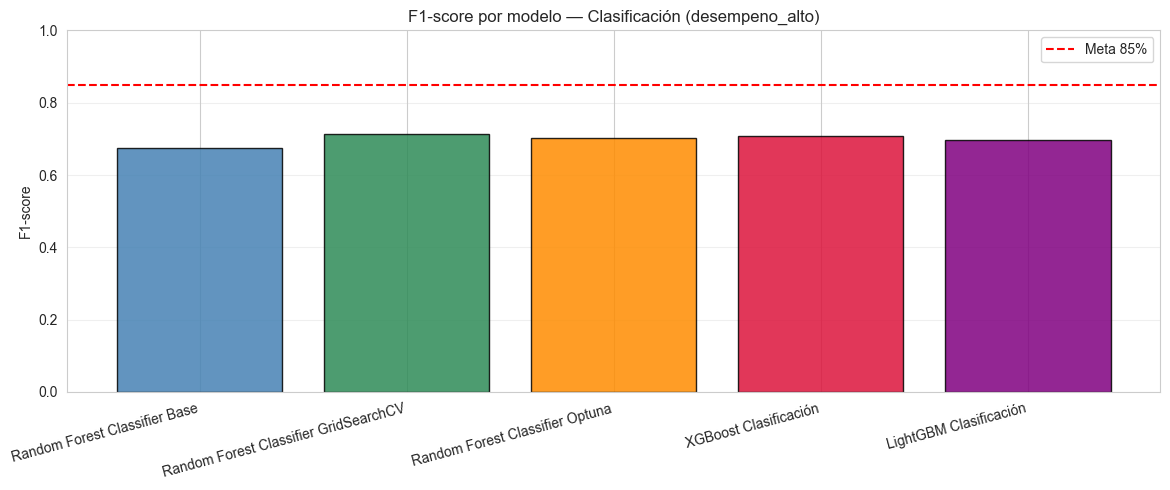

In [64]:
# ── Comparación clasificación (todos los modelos) ────────────────────────────
filas_clf = [resultado_clf_base, resultado_clf_grid, resultado_clf_optuna] + resultados_xgb_lgb_clf
tabla_completa_clf = pd.DataFrame(filas_clf).reset_index(drop=True)

print("=== Comparación Clasificación ===")
display(tabla_completa_clf.sort_values("f1_score", ascending=False).reset_index(drop=True))

# Mejor modelo global de clasificación.
idx_mejor_clf = tabla_completa_clf["f1_score"].astype(float).idxmax()
mejor_clf_global = tabla_completa_clf.loc[idx_mejor_clf, "modelo"]
print(f"\nMejor modelo clasificacion: {mejor_clf_global}")

# ── Comparación regresión (todos los modelos) ────────────────────────────────
filas_reg = [resultado_reg_base, resultado_reg_grid, resultado_reg_optuna] + resultados_xgb_lgb_reg
tabla_completa_reg = pd.DataFrame(filas_reg).reset_index(drop=True)

print("\n=== Comparación Regresión ===")
display(tabla_completa_reg.sort_values("rmse", ascending=True).reset_index(drop=True))

idx_mejor_reg = tabla_completa_reg["rmse"].astype(float).idxmin()
mejor_reg_global = tabla_completa_reg.loc[idx_mejor_reg, "modelo"]
print(f"\nMejor modelo regresión: {mejor_reg_global}")

# ── Gráfico comparativo clasificación ───────────────────────────────────────
colores_all = ["steelblue", "seagreen", "darkorange", "crimson", "purple"]
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(tabla_completa_clf))
ax.bar(x, tabla_completa_clf["f1_score"].astype(float), color=colores_all[:len(tabla_completa_clf)],
       edgecolor="black", alpha=0.85)
ax.axhline(0.85, color="red", linestyle="--", lw=1.5, label="Meta 85%")
ax.set_xticks(x)
ax.set_xticklabels(tabla_completa_clf["modelo"], rotation=15, ha="right")
ax.set_ylim(0, 1.0)
ax.set_ylabel("F1-score")
ax.set_title("F1-score por modelo — Clasificación (desempeno_alto)")
ax.legend()
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig(os.path.join(ruta_plots, "04_comparacion_clf_completa.png"), dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# Actualizar pipeline_final_clf y pipeline_final_reg según el mejor modelo global.
pipelines_clf = {
    "Random Forest Classifier Base":               pipeline_clf_base,
    "Random Forest Classifier GridSearchCV":        grid_clf.best_estimator_,
    "Random Forest Classifier RandomizedSearchCV":  random_search_clf.best_estimator_,
    "Random Forest Classifier Optuna":              pipeline_clf_optuna,
}
if xgb_disponible and optuna_disponible:
    pipelines_clf["XGBoost Clasificación"] = pipeline_xgb_clf
if lgbm_disponible and optuna_disponible:
    pipelines_clf["LightGBM Clasificación"] = pipeline_lgb_clf

pipelines_reg = {
    "Random Forest Regressor Base":               pipeline_reg_base,
    "Random Forest Regressor GridSearchCV":        grid_reg.best_estimator_,
    "Random Forest Regressor RandomizedSearchCV":  random_search_reg.best_estimator_,
    "Random Forest Regressor Optuna":              pipeline_reg_optuna,
}
if xgb_disponible and optuna_disponible:
    pipelines_reg["XGBoost Regresión"] = pipeline_xgb_reg
if lgbm_disponible and optuna_disponible:
    pipelines_reg["LightGBM Regresión"] = pipeline_lgb_reg

pipeline_final_clf = pipelines_clf[mejor_clf_global]
pipeline_final_reg = pipelines_reg[mejor_reg_global]

print(f"Pipeline final clasificación: {mejor_clf_global}")
print(f"Pipeline final regresión:     {mejor_reg_global}")

# 11. Real vs predicho del mejor modelo de regresión

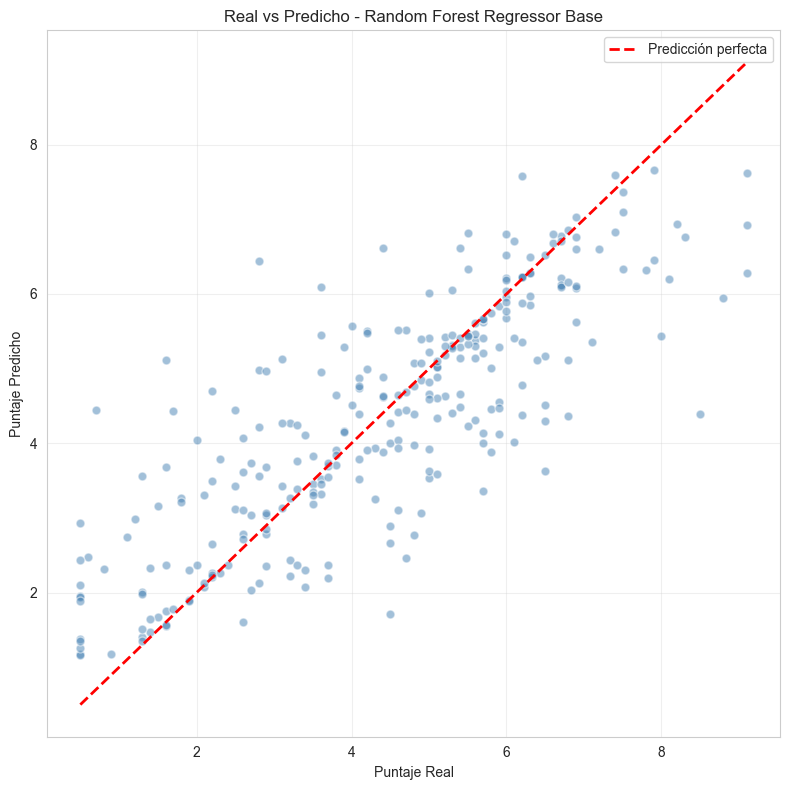

In [66]:
y_pred_final_reg = pipeline_final_reg.predict(X_test_reg)

plt.figure(figsize=(8, 8))
plt.scatter(y_test_reg, y_pred_final_reg, alpha=0.5,
            color="steelblue", edgecolors="white", s=40)

lim = [min(y_test_reg.min(), y_pred_final_reg.min()),
       max(y_test_reg.max(), y_pred_final_reg.max())]
plt.plot(lim, lim, color="red", linestyle="--", lw=2, label="Predicción perfecta")

plt.xlabel("Puntaje Real")
plt.ylabel("Puntaje Predicho")
plt.title(f"Real vs Predicho - {mejor_reg_global}")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(ruta_plots, '04_real_vs_predicho.png'), dpi=150, bbox_inches='tight')
plt.show()

# 12. Importancia de variables del mejor modelo final


Top 15 Variables - Clasificación (target: desempeno_alto):


,variable,importancia
18,num__evaluador_media,0.171265
26,num__competencia_combinada_log,0.102594
12,num__competencia_combinada,0.096407
10,num__competencias_tecnicas,0.096167
17,num__prev_puntaje,0.088603
11,num__competencias_blandas,0.080532
29,num__ratio_tec_blanda,0.042983
19,num__dept_media,0.023334
16,num__periodo_num,0.015897
31,cat__x0_Finanzas,0.012342


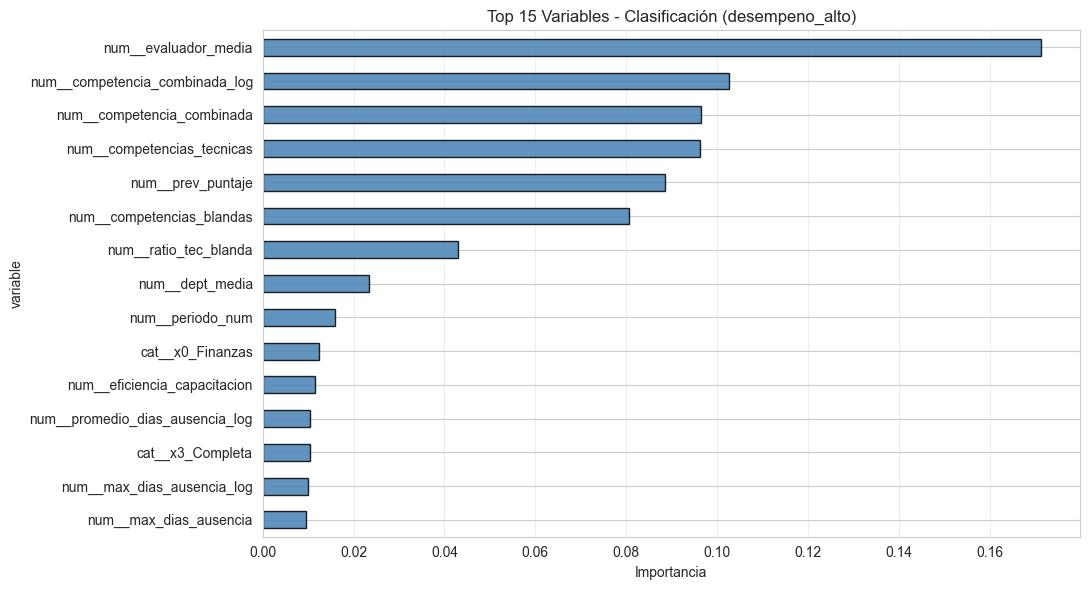


Top 15 Variables - Regresión (target: puntaje_desempeno):


,variable,importancia
18,num__evaluador_media,0.416769
12,num__competencia_combinada,0.198356
26,num__competencia_combinada_log,0.179729
17,num__prev_puntaje,0.072948
10,num__competencias_tecnicas,0.026736
29,num__ratio_tec_blanda,0.017668
11,num__competencias_blandas,0.011841
16,num__periodo_num,0.006556
19,num__dept_media,0.005498
38,cat__x0_Ventas,0.003422


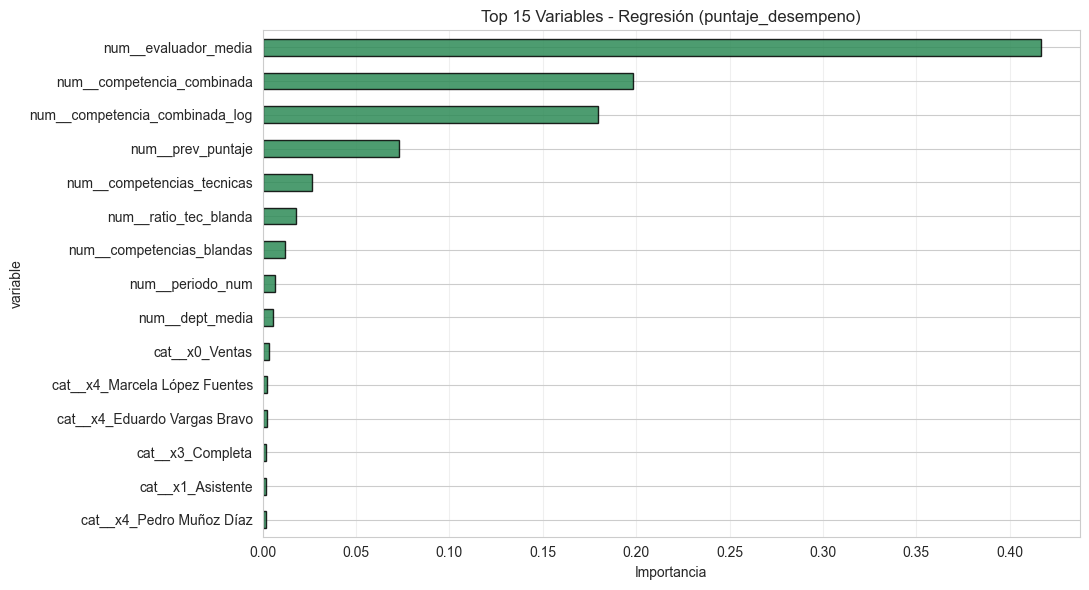

In [67]:
for nombre_pipe, pipeline_fin, titulo in [
    ("Clasificación", pipeline_final_clf, "desempeno_alto"),
    ("Regresión",    pipeline_final_reg, "puntaje_desempeno")
]:
    modelo_fin = pipeline_fin.named_steps["modelo"]

    if not hasattr(modelo_fin, "feature_importances_"):
        print(f"Modelo de {nombre_pipe} no expone feature_importances_.")
        continue

    prepro = pipeline_fin.named_steps["preprocesamiento"]

    try:
        nombres_num = prepro.named_transformers_["num"]["imputer"].feature_names_in_.tolist()
        nombres_cat = prepro.named_transformers_["cat"]["onehot"].get_feature_names_out().tolist()
        nombres_features = [f"num__{n}" for n in nombres_num] + [f"cat__{n}" for n in nombres_cat]
    except Exception:
        nombres_features = [f"feature_{i}" for i in range(len(modelo_fin.feature_importances_))]

    df_imp = pd.DataFrame({
        "variable":    nombres_features,
        "importancia": modelo_fin.feature_importances_
    }).sort_values(by="importancia", ascending=False)

    print(f"\nTop 15 Variables - {nombre_pipe} (target: {titulo}):")
    display(df_imp.head(15))

    plt.figure(figsize=(11, 6))
    color = "steelblue" if nombre_pipe == "Clasificación" else "seagreen"
    df_imp.head(15).plot(
        kind="barh", x="variable", y="importancia",
        color=color, edgecolor="black", alpha=0.85, ax=plt.gca()
    )
    plt.gca().invert_yaxis()
    plt.title(f"Top 15 Variables - {nombre_pipe} ({titulo})")
    plt.xlabel("Importancia")
    plt.legend().remove()
    plt.grid(alpha=0.3, axis="x")
    plt.tight_layout()
    fname = f"04_importancia_{nombre_pipe.lower()}.png"
    plt.savefig(os.path.join(ruta_plots, fname), dpi=150, bbox_inches='tight')
    plt.show()

# 13. Resumen final del notebook

## Resultado final — Clasificación (`desempeno_alto`)

El modelo final de clasificación fue seleccionado automáticamente según el mayor F1-score entre los tres enfoques.

Con las variables extendidas (prev_puntaje, evaluador_media, dept_media e interacciones), el Random Forest tiene acceso a las señales más fuertes del dataset — en particular el historial previo del empleado y el sesgo del evaluador.

## Resultado final — Regresión (`puntaje_desempeno`)

El modelo final de regresión fue seleccionado por menor RMSE entre los tres enfoques.

Las variables temporales y de evaluador explican una parte importante de la varianza en `puntaje_desempeno`, por lo que su inclusión mejora directamente el R² y reduce el error.

---

## Conclusión general

Los modelos de este notebook optimizan los hiperparámetros de Random Forest con:

- **GridSearchCV** (cv=5): búsqueda en grilla con validación cruzada correcta sobre train.
- **Optuna** (cv=5, 30 trials): búsqueda bayesiana sin data leakage — el test set nunca participa en la optimización.

La selección del modelo final se hace comparando métricas sobre el test set solo al final, no durante la búsqueda.

# 14. Persistencia de modelos finales

Después de definir las configuraciones finales de los modelos, se procede a guardar los modelos entrenados utilizando `joblib`.

La persistencia de modelos permite:

- reutilizar los modelos sin reentrenarlos;
- mantener versiones finales listas para uso futuro;
- facilitar una posible implementación en entornos de RRHH reales.


In [68]:
ruta_modelos = os.path.join(project_root, 'data/06_models')
os.makedirs(ruta_modelos, exist_ok=True)

# Guardado del modelo de clasificación (el mejor entre todos los modelos).
ruta_clf = os.path.join(ruta_modelos, 'modelo_clasificacion_final.pkl')
joblib.dump(pipeline_final_clf, ruta_clf)
print(f"Modelo de clasificación guardado: {mejor_clf_global}")

# Guardado del modelo de regresión (el mejor entre todos los modelos).
ruta_reg = os.path.join(ruta_modelos, 'modelo_regresion_final.pkl')
joblib.dump(pipeline_final_reg, ruta_reg)
print(f"Modelo de regresión guardado:     {mejor_reg_global}")

Modelo de clasificación guardado: Random Forest Classifier GridSearchCV
Modelo de regresión guardado:     Random Forest Regressor Base


In [69]:
# Verificación: cargar y predecir con los modelos guardados.
modelo_clf_cargado = joblib.load(os.path.join(ruta_modelos, 'modelo_clasificacion_final.pkl'))
modelo_reg_cargado = joblib.load(os.path.join(ruta_modelos, 'modelo_regresion_final.pkl'))

print("Modelos cargados correctamente.")

# Verificación rápida.
pred_clf_verif = modelo_clf_cargado.predict(X_test_clf[:5])
pred_reg_verif = modelo_reg_cargado.predict(X_test_reg[:5])

print("\nPredicciones clasificación (5 muestras):", pred_clf_verif)
print("Predicciones regresión     (5 muestras):", pred_reg_verif.round(3))

Modelos cargados correctamente.

Predicciones clasificación (5 muestras): [0 1 1 0 0]
Predicciones regresión     (5 muestras): [5.963 5.353 5.31  3.251 6.777]
